In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
train_df = pd.read_parquet('train.parquet')
test_df = pd.read_parquet('test.parquet')

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
0,80,5169956,8,6,1101,4222,410,0,137.625,185.758628,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS
1,80,229,2,0,12,0,6,6,6.000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS
2,80,5001928,3,1,12,0,6,0,4.000,3.464102,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS
3,80,5125872,8,7,1659,2514,467,0,207.375,221.278065,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS
4,80,214,2,0,12,0,6,6,6.000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS


In [27]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
train_df['Attack']= encoder.fit_transform(train_df['Attack'])
train_df['Attack'].value_counts()

Attack
0    1720966
4     189135
3      29999
5      25501
2       7417
6       1718
1        974
Name: count, dtype: int64

In [28]:
import joblib
joblib.dump(encoder,r"scalers\label_enoder.joblib")


['scalers\\label_enoder.joblib']

In [29]:
test_df['Attack']= encoder.transform(test_df['Attack'])
test_df['Attack'].value_counts()

Attack
0    395106
3     98022
5     79290
4      4871
2      2039
1       981
6       433
Name: count, dtype: int64

In [30]:
# Printing corresponding attack type for each encoded value
encoded_values = train_df['Attack'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {encoder.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Port Scan
6: Web Attack


In [31]:
corr_train = train_df.corr(numeric_only=True).round(3)

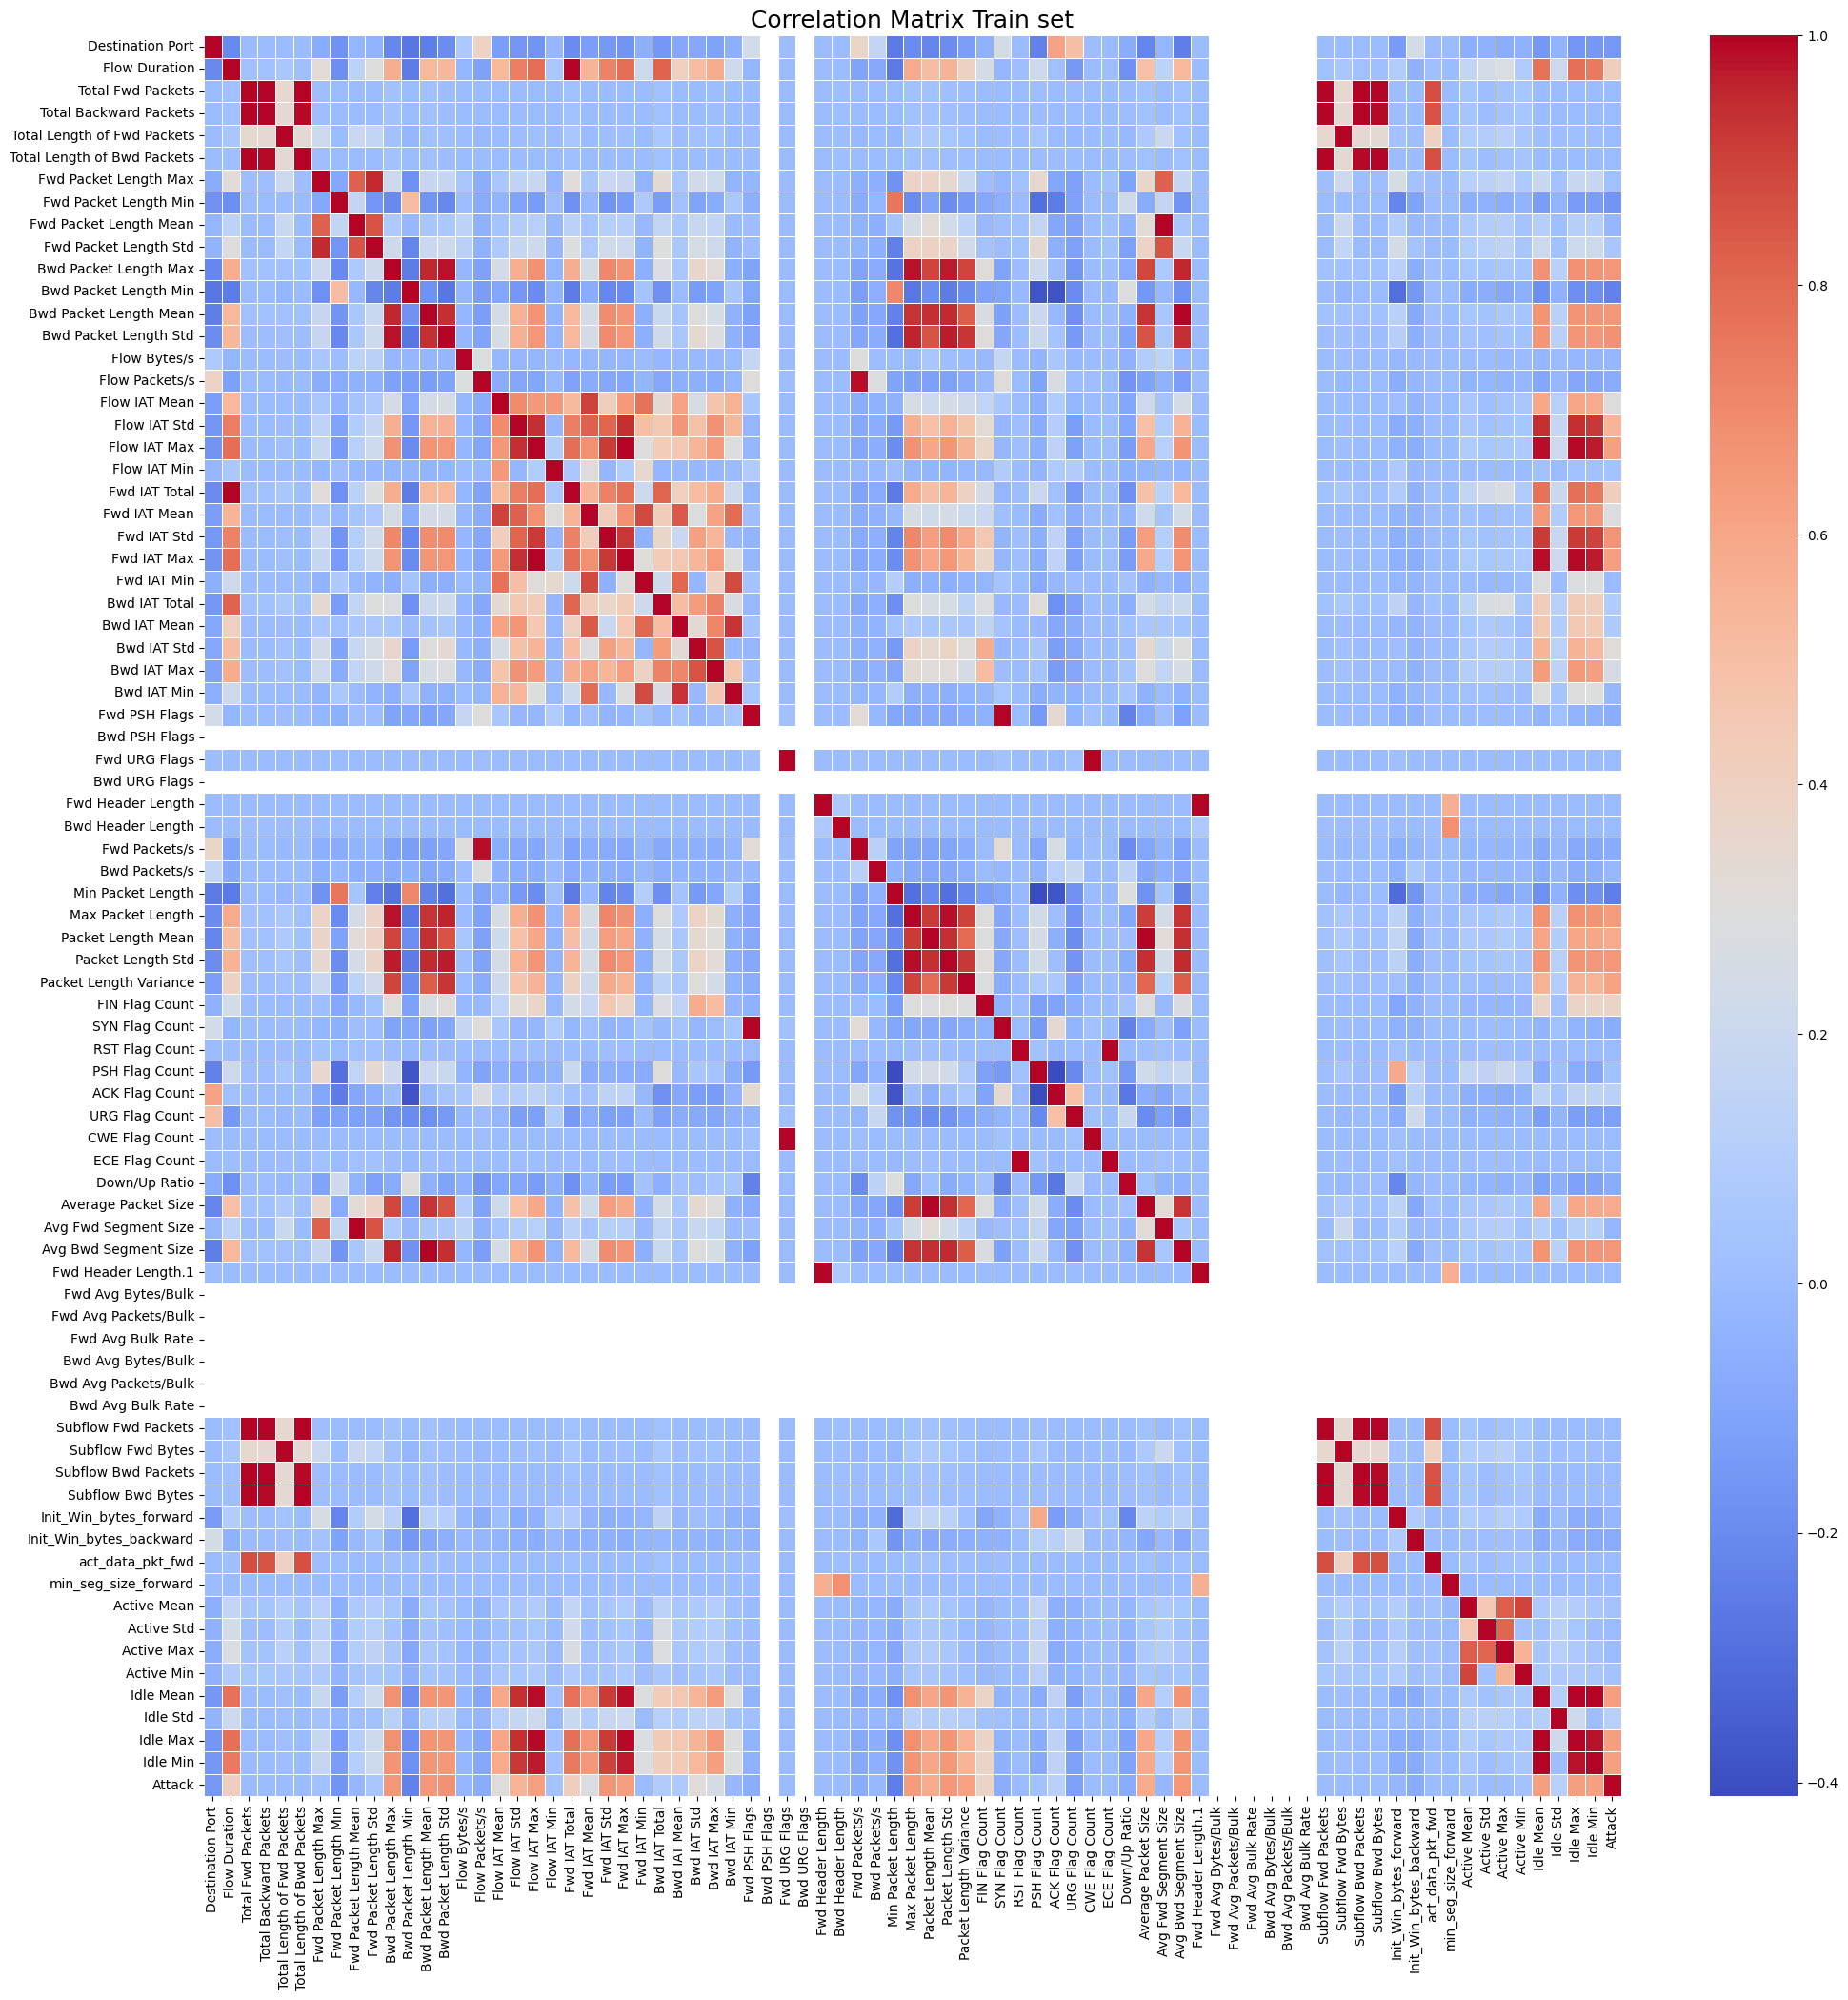

In [32]:
fig,ax = plt.subplots(figsize=(24,24))
sns.heatmap(corr_train,cmap = 'coolwarm',annot=False,linewidth=0.5)
plt.title("Correlation Matrix Train set",fontsize=18)
plt.show()

In [33]:
corr_test = test_df.corr(numeric_only=True).round(3)

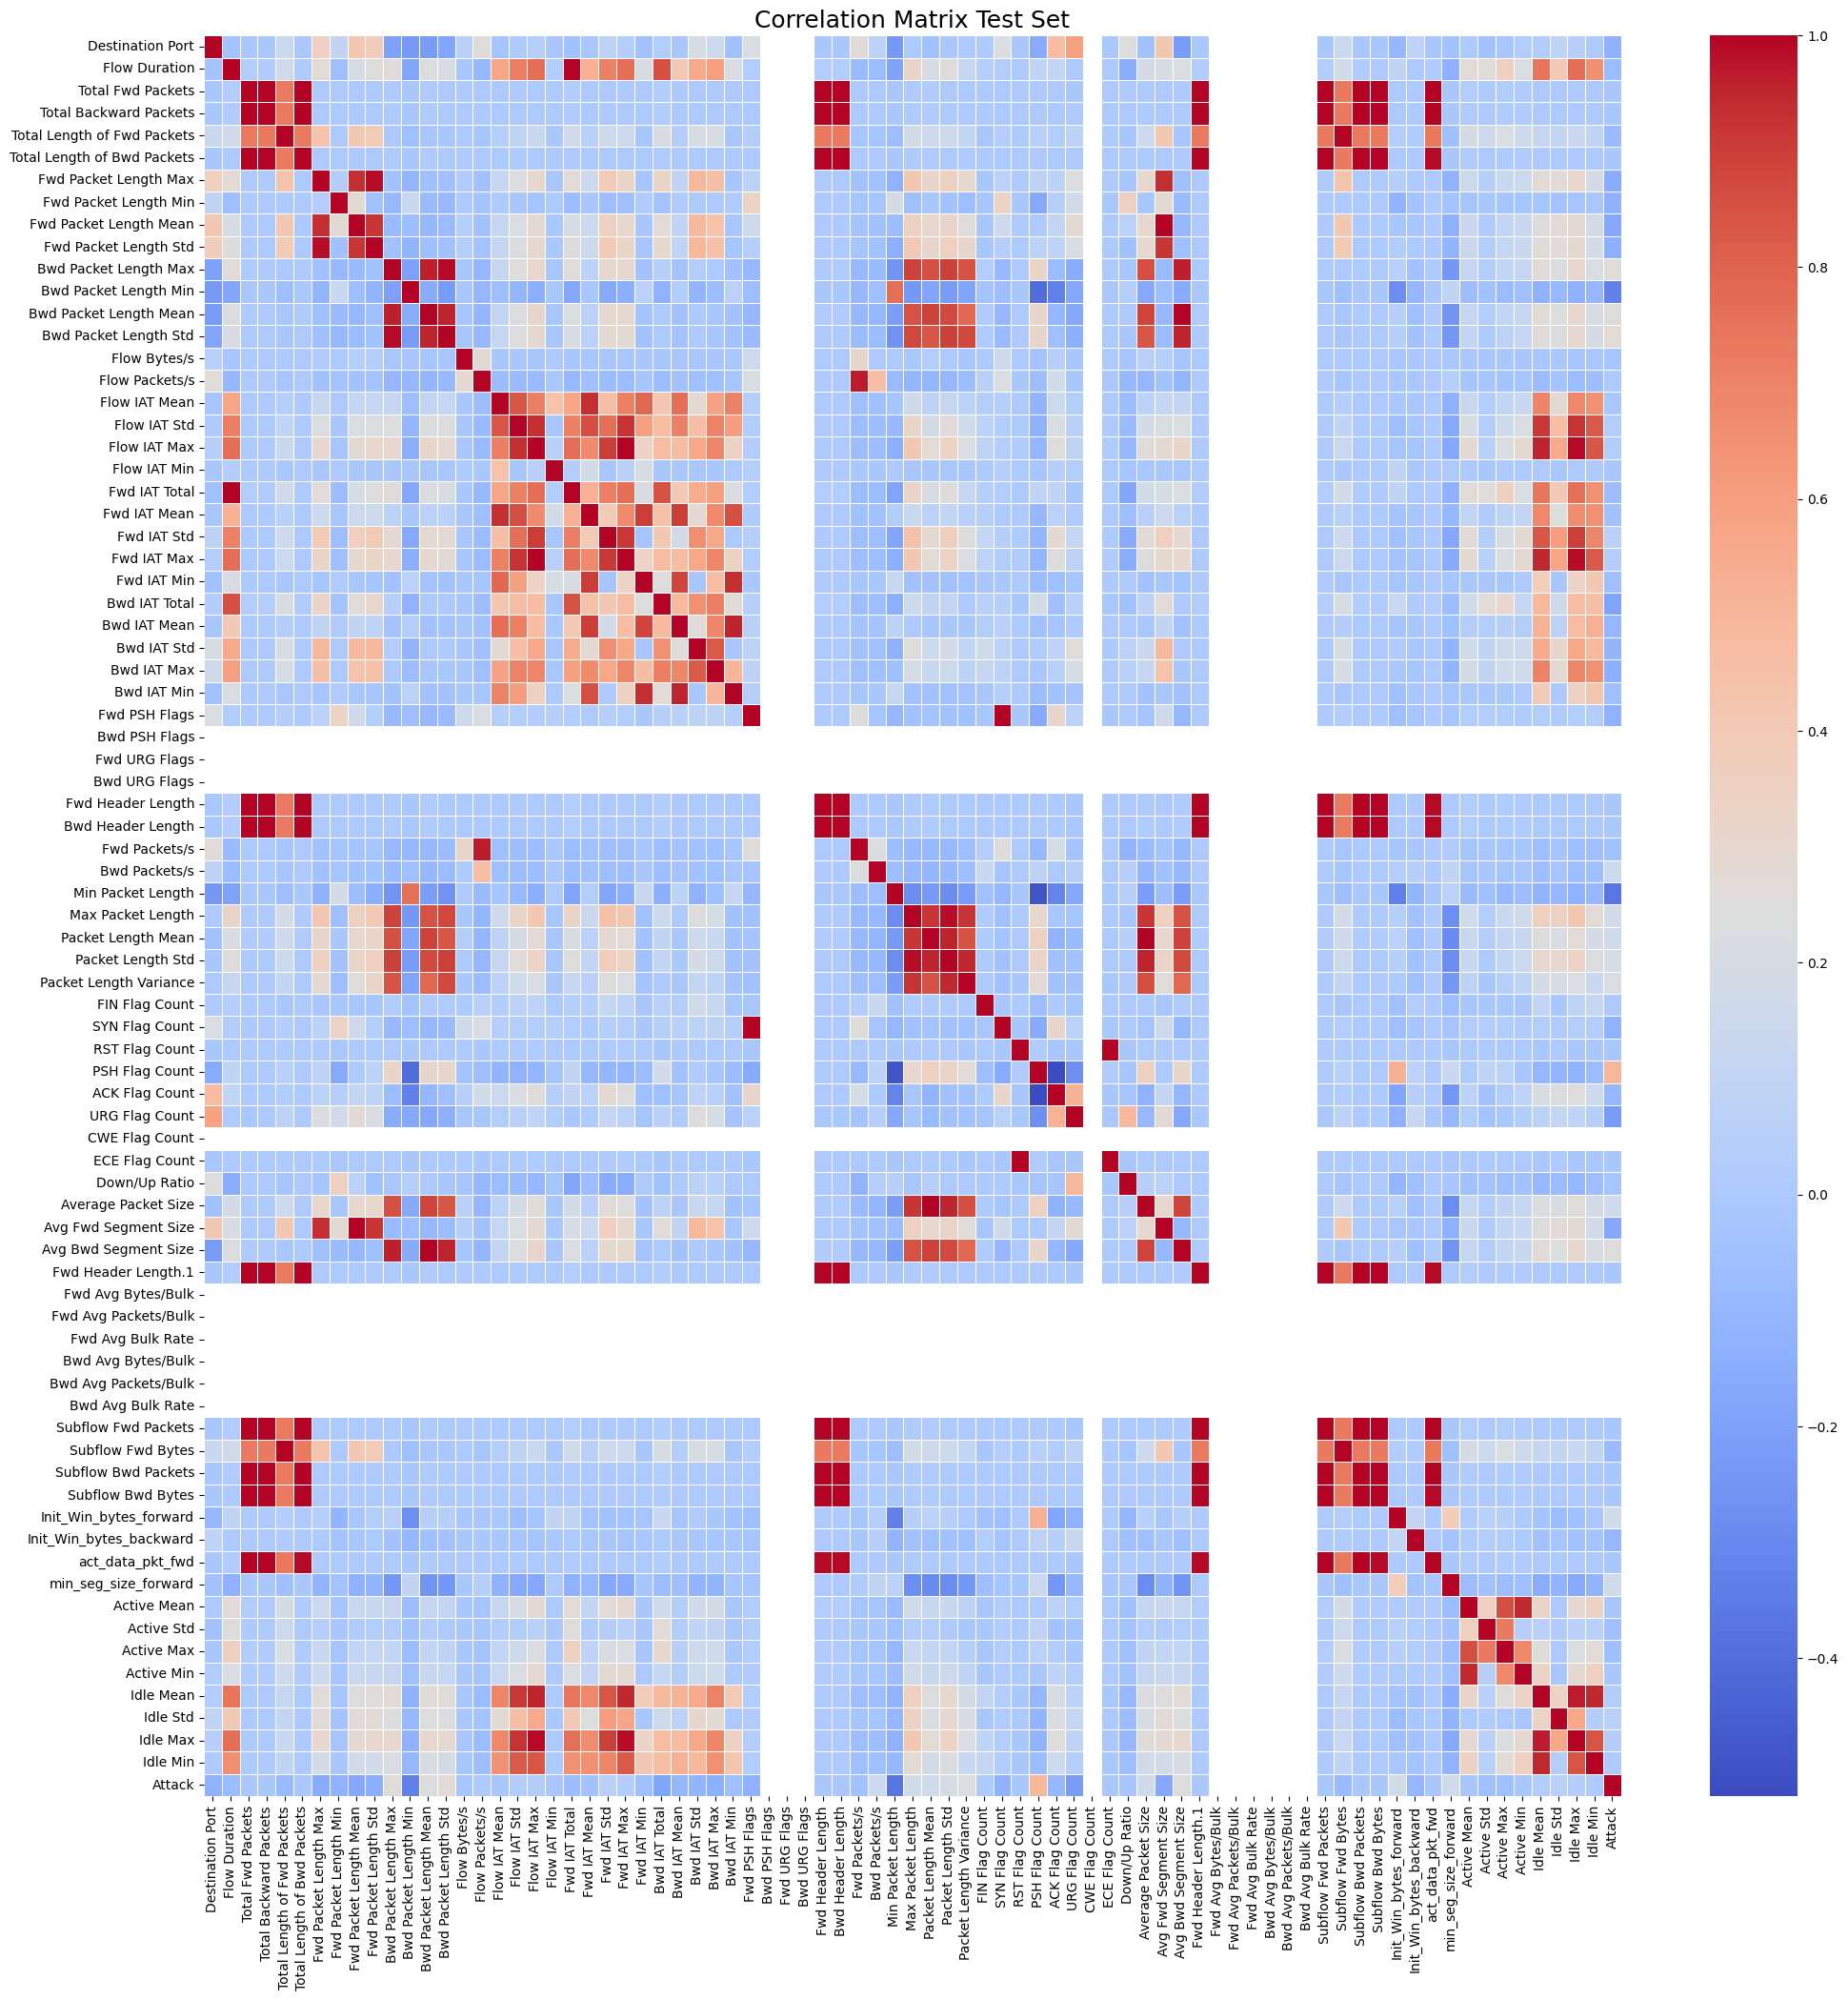

In [34]:
fig,ax = plt.subplots(figsize=(24,24))
sns.heatmap(corr_test,cmap = 'coolwarm',annot=False,linewidth=0.5)
plt.title("Correlation Matrix Test Set",fontsize=18)
plt.show()

In [35]:
attack_corr = corr_train['Attack']
THRESHOLD = 0.1
pos_corr = attack_corr[(attack_corr > THRESHOLD) & (attack_corr < 1)]
pos_corr = pos_corr.sort_values(ascending=False)
print("Features with positive correlation with 'Attack' in Descending Order:\n")
for i, (feature, corr_value) in enumerate(pos_corr.items(), start=1):
    print(f"{i:<3} {feature:<24} : {corr_value}")

Features with positive correlation with 'Attack' in Descending Order:

1   Bwd Packet Length Std    : 0.671
2   Fwd IAT Std              : 0.661
3   Bwd Packet Length Max    : 0.657
4   Packet Length Std        : 0.655
5   Avg Bwd Segment Size     : 0.653
6   Bwd Packet Length Mean   : 0.653
7   Max Packet Length        : 0.637
8   Idle Max                 : 0.63
9   Idle Mean                : 0.627
10  Fwd IAT Max              : 0.626
11  Flow IAT Max             : 0.625
12  Idle Min                 : 0.62
13  Packet Length Variance   : 0.619
14  Average Packet Size      : 0.586
15  Packet Length Mean       : 0.584
16  Flow IAT Std             : 0.545
17  Fwd IAT Total            : 0.412
18  Flow Duration            : 0.411
19  FIN Flag Count           : 0.374
20  Bwd IAT Std              : 0.308
21  Flow IAT Mean            : 0.303
22  Fwd IAT Mean             : 0.282
23  Bwd IAT Max              : 0.255
24  ACK Flag Count           : 0.127
25  Idle Std                 : 0.113


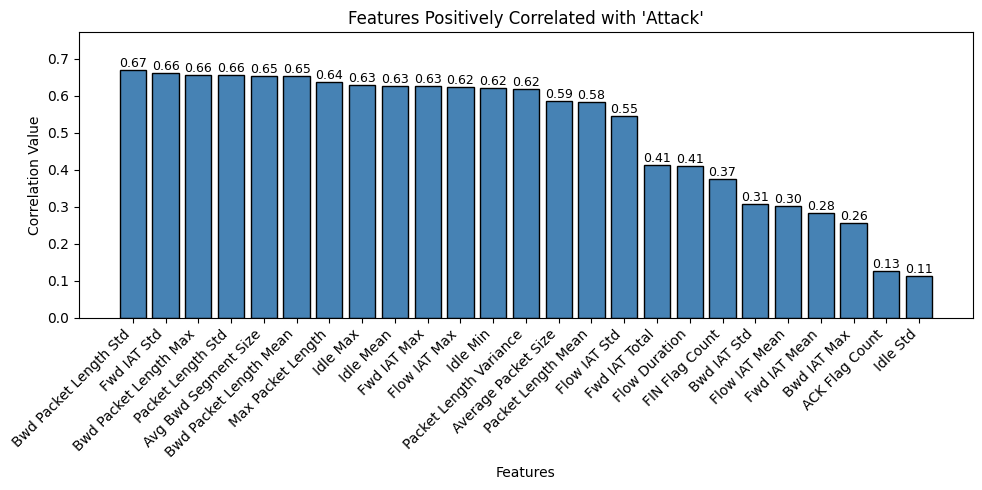

In [36]:
features = pos_corr.index
values = pos_corr.values

plt.figure(figsize=(10, 5))

bars = plt.bar(features, values, color="steelblue", edgecolor="black")

# value labels on top
for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        v,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

plt.title("Features Positively Correlated with 'Attack'")
plt.xlabel("Features")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.ylim(0,max(values)*1.15)
plt.show()

In [37]:
print(f"Imp features = {len(pos_corr)}")

Imp features = 25


In [38]:
type(pos_corr)

pandas.core.series.Series

In [39]:
imp_features = pos_corr.index.tolist()

In [40]:
std = train_df.std(numeric_only = True)
zero_std_cols = std[std == 0].index.tolist()
zero_std_cols #DEAD or Useless Featuers

['Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [ ]:
train_df.to_parquet('train_final.parquet')
test_df.to_parquet('test_final.parquet')